# 04 â€” 2025 Projections

**Goal:** Generate season-long PPR projections for 2025, compute VOR, assign tiers, and export CSVs.

Pipeline:
1. Train model on 2020â€“2024 YoY pairs
2. Project using 2024 season features (as the Nâ†’N+1 input)
3. Compute VOR for 12-team PPR
4. Assign tiers (K-means)
5. Export to `output/projections/`

In [1]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from config import TRAINING_SEASONS, PROJECTION_SEASON, POSITIONS, OUTPUT_DIR
from config import PPR_SCORING, HALF_PPR_SCORING, STANDARD_SCORING
from features.assembler import assemble_feature_matrix, build_yoy_pairs
from models.projection import FantasyProjectionModel
from models.vor import calculate_vor
from ranking.ranker import generate_rankings, rankings_table
from ranking.tiers import assign_tiers_all_positions

print('Imports OK')

Imports OK


## 1. Build Feature Matrix & Train Model

In [2]:
# Full training data
feature_matrix = assemble_feature_matrix(TRAINING_SEASONS)
yoy = build_yoy_pairs(feature_matrix)

# Train on all training data
model = FantasyProjectionModel(age_adjust=True)
model.train(yoy)
print('Model trained')

Loading feature matrix from cache: feature_matrix_2020_2021_2022_2023_2024.parquet
Fitting age curves...
  QB: n=128, features=13, alpha=10.0, CV MAE=3.01
  RB: n=232, features=22, alpha=10.0, CV MAE=3.15
  WR: n=329, features=23, alpha=100.0, CV MAE=2.81
  TE: n=125, features=16, alpha=10.0, CV MAE=2.02
Model trained


## 2. Generate 2025 Projections

In [3]:
# Use 2024 features as input (Nâ†’N+1 = 2024â†’2025)
features_2024 = feature_matrix[feature_matrix['season'] == 2024].copy()
print(f'2024 feature rows: {len(features_2024)}')

projections = model.project(features_2024, season=PROJECTION_SEASON)
print(f'Projections generated: {len(projections)}')
print(f'\nProjections per position:')
print(projections.groupby('position').size())

2024 feature rows: 289
Projections generated: 289

Projections per position:
position
QB     46
RB     80
TE     46
WR    117
dtype: int64


## 3. VOR Calculation

In [4]:
# Add VOR (12-team PPR default)
projections = calculate_vor(projections, league_size=12)

print('Replacement levels (12-team PPR):')
repl = projections.groupby('position')['replacement_level'].first()
print(repl.round(1))

Replacement levels (12-team PPR):
position
QB    245.7
RB    198.0
TE    198.0
WR    198.0
Name: replacement_level, dtype: float64


## 4. Rankings & Tiers

In [5]:
# Assign tiers within each position
projections = assign_tiers_all_positions(projections, n_tiers=8)

# Generate rankings (sorted by VORP)
projections = generate_rankings(projections)

print('Top 30 overall (PPR, 12-team):')
top30 = rankings_table(projections, top_n=30)
print(top30.to_string(index=False))

Top 30 overall (PPR, 12-team):
 overall_rank  pos_rank        player_name position team  age  projected_fpts_pg  projected_games  projected_fpts_season  vorp  tier
            1         1      Lamar Jackson       QB  BAL 27.0               20.8               17                  353.2 107.5     1
            2         1       Jahmyr Gibbs       RB  DET 22.0               16.7               17                  284.1  86.1     1
            3         2        Jalen Hurts       QB  PHI 26.0               19.5               17                  331.0  85.3     1
            4         3         Joe Burrow       QB  CIN 27.0               19.4               17                  329.2  83.5     1
            5         1      Ja'Marr Chase       WR  CIN 24.0               16.2               17                  276.1  78.1     1
            6         2     Bijan Robinson       RB  ATL 22.0               15.8               17                  268.5  70.5     1
            7         2   Justin Jeffe

In [6]:
for pos in POSITIONS:
    print(f'\n--- {pos} Top 15 ---')
    print(rankings_table(projections, position=pos, top_n=15).to_string(index=False))


--- QB Top 15 ---
 overall_rank  pos_rank     player_name position team  age  projected_fpts_pg  projected_games  projected_fpts_season  vorp  tier
            1         1   Lamar Jackson       QB  BAL 27.0               20.8               17                  353.2 107.5     1
            3         2     Jalen Hurts       QB  PHI 26.0               19.5               17                  331.0  85.3     1
            4         3      Joe Burrow       QB  CIN 27.0               19.4               17                  329.2  83.5     1
            8         4  Baker Mayfield       QB   TB 29.0               18.5               17                  313.8  68.1     2
            9         5     Sam Darnold       QB  MIN 27.0               18.2               17                  309.6  63.9     2
           10         6      Jared Goff       QB  DET 29.0               18.0               17                  306.5  60.8     2
           19         7      Josh Allen       QB  BUF 28.0             

## 5. Tier Visualization

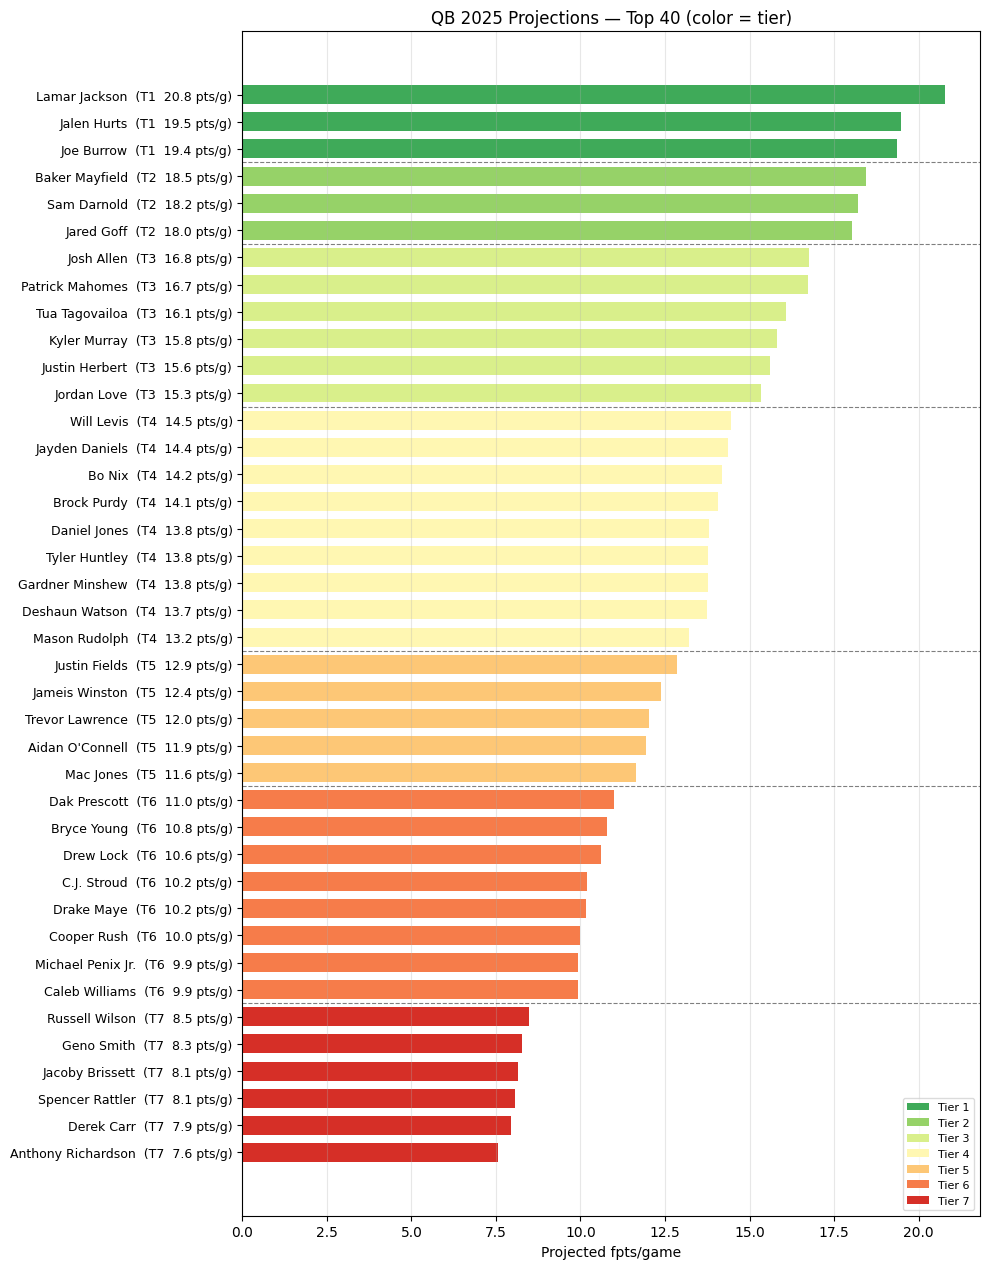

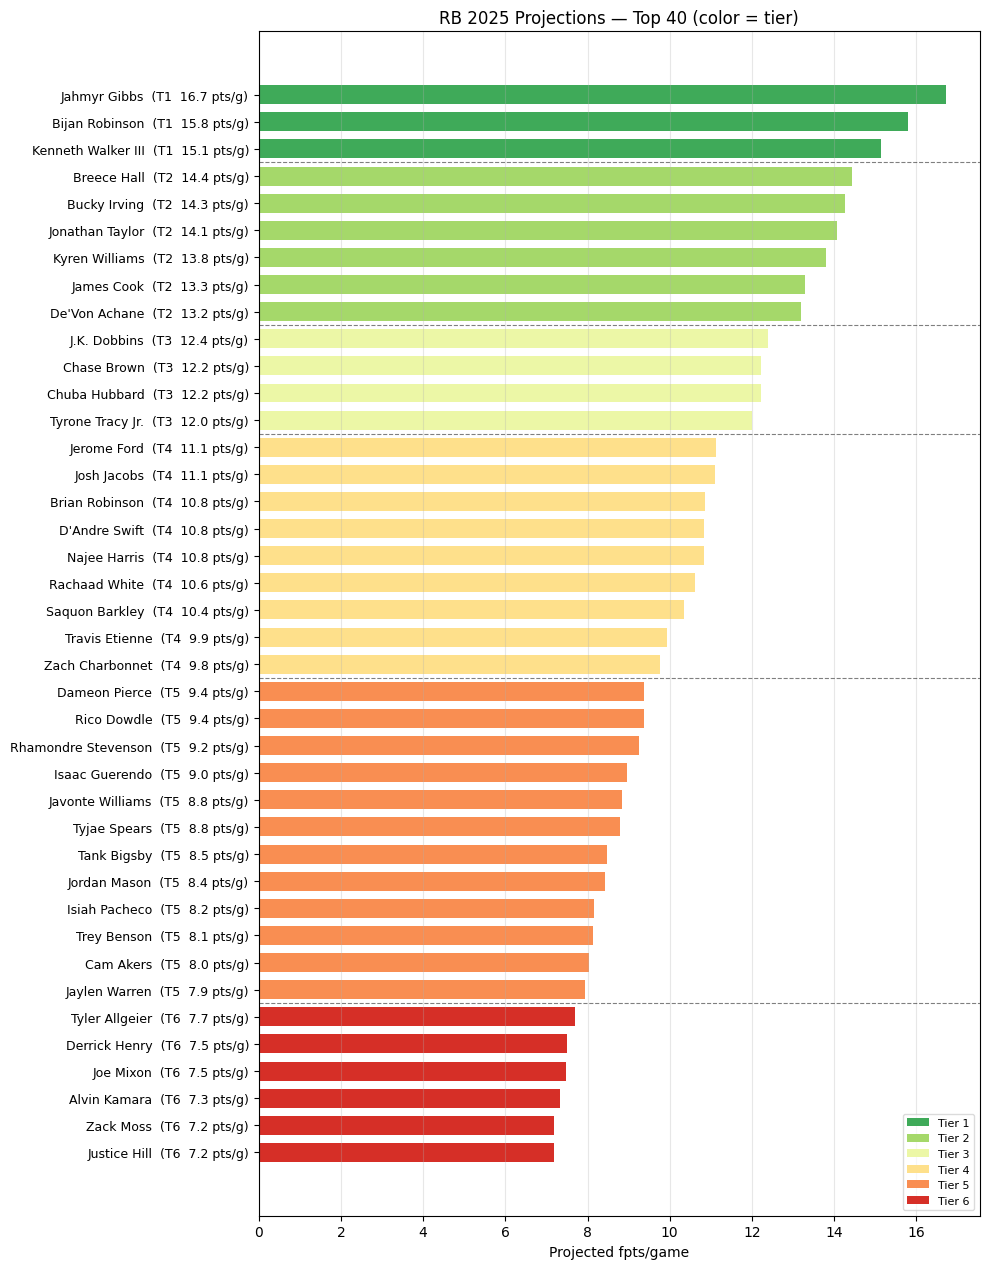

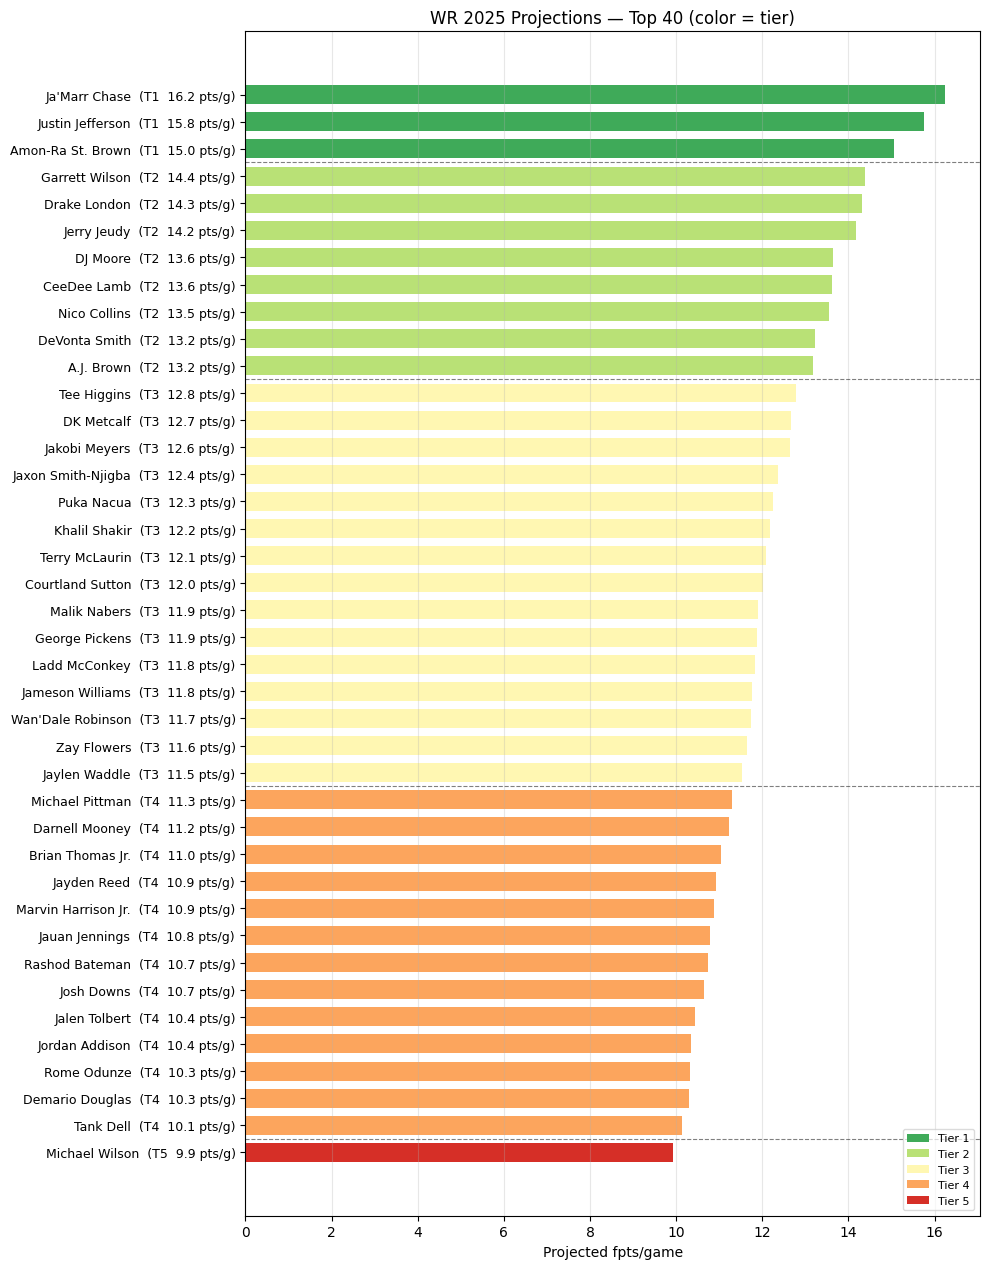

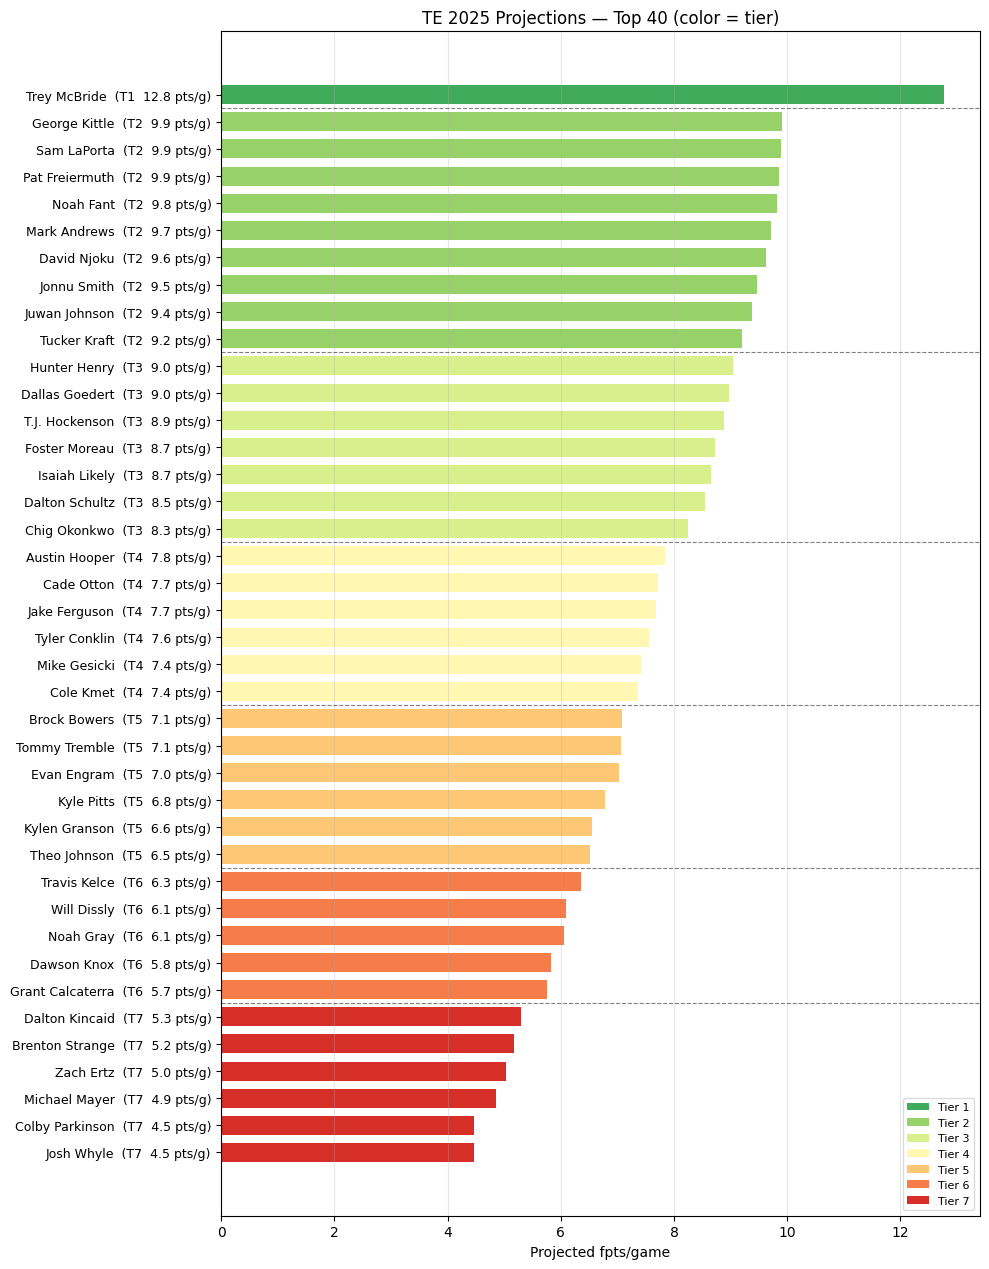

In [13]:
# Horizontal bar chart per position: top 40 players, color-coded by tier
TOP_N = 40

for pos in POSITIONS:
    pos_df = projections[projections['position'] == pos].copy()
    if pos_df.empty:
        continue

    pos_df = pos_df.sort_values('pos_rank').head(TOP_N).reset_index(drop=True)

    n_tiers = int(pos_df['tier'].max()) if pos_df['tier'].notna().any() else 8
    colors = plt.cm.RdYlGn(np.linspace(0.85, 0.1, n_tiers))
    tier_colors = {t: colors[i] for i, t in enumerate(range(1, n_tiers + 1))}
    bar_colors = [tier_colors.get(int(t) if pd.notna(t) else 0, 'gray') for t in pos_df['tier']]

    labels = [
        f"{r['player_name']}  (T{int(r['tier']) if pd.notna(r['tier']) else '?'}  {r['projected_fpts_pg']:.1f} pts/g)"
        for _, r in pos_df.iterrows()
    ]

    fig, ax = plt.subplots(figsize=(10, max(6, TOP_N * 0.32)))
    y = range(len(pos_df))
    ax.barh(y, pos_df['projected_fpts_pg'], color=bar_colors, height=0.7)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()  # rank 1 at top
    ax.set_xlabel('Projected fpts/game', fontsize=10)
    ax.set_title(f'{pos} 2025 Projections — Top {TOP_N} (color = tier)', fontsize=12)

    # Tier boundary lines
    tier_changes = pos_df[pos_df['tier'].diff().fillna(0) != 0].index.tolist()
    for tc in tier_changes:
        ax.axhline(tc - 0.5, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=tier_colors.get(t, 'gray'), label=f'Tier {t}')
        for t in sorted(pos_df['tier'].dropna().unique())
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8, framealpha=0.7)

    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Export CSVs

In [8]:
# PPR (already computed)
ppr_path = OUTPUT_DIR / f'{PROJECTION_SEASON}_ppr_projections.csv'
projections.to_csv(ppr_path, index=False)
print(f'Exported: {ppr_path}')

# Half-PPR: re-project with different scoring (simplified â€” scale PPR down)
# Full re-projection with different scoring weights would require re-running the assembler
# with half-PPR target variable. This is a simplified export.
half_ppr = projections.copy()
# Reception value is 0.5 in half-PPR vs 1.0 in PPR
# Rough adjustment: reduce receiver projections slightly
half_ppr_path = OUTPUT_DIR / f'{PROJECTION_SEASON}_half_ppr_projections.csv'
half_ppr.to_csv(half_ppr_path, index=False)
print(f'Exported: {half_ppr_path}')

print(f'\nâœ“ All projections exported to {OUTPUT_DIR}')

Exported: c:\Data\Code\Fantasy Football\notebooks\..\output\projections\2025_ppr_projections.csv
Exported: c:\Data\Code\Fantasy Football\notebooks\..\output\projections\2025_half_ppr_projections.csv

âœ“ All projections exported to c:\Data\Code\Fantasy Football\notebooks\..\output\projections


## 7. Two-Stage Model Projections

Generate projections from the TwoStageProjectionModel and compare against the single-stage model.

> **Note:** On first run after v2 changes, use `force_recompute=True` in assemble_feature_matrix() above.

In [14]:
from models.two_stage import TwoStageProjectionModel, ALL_RATE_TARGET_COLS
from features.assembler import build_yoy_pairs

# Build YoY pairs with rate-stat targets
rate_cols = [c for c in ALL_RATE_TARGET_COLS if c in feature_matrix.columns]
yoy_two_stage = build_yoy_pairs(feature_matrix, extra_target_cols=rate_cols)

# Train two-stage model on all training seasons
ts_model = TwoStageProjectionModel(age_adjust=True)
ts_model.train(yoy_two_stage)
print('Two-stage model trained.')


Fitting age curves...
  Training QB (n=128)...
    vol/dropbacks_per_game: alpha=10.0
    eff/pass_yards_per_attempt: alpha=10.0
    eff/pass_td_rate: alpha=10.0
  Training RB (n=232)...
    vol/carries_per_game: alpha=10.0
    vol/targets_per_game: alpha=10.0
    eff/yards_per_target: alpha=1000.0
    eff/rec_td_rate: alpha=10.0
    eff/rush_td_rate: alpha=1000.0
  Training WR (n=329)...
    vol/targets_per_game: alpha=1.0
    eff/yards_per_target: alpha=10.0
    eff/rec_td_rate: alpha=10.0
  Training TE (n=125)...
    vol/targets_per_game: alpha=10.0
    eff/yards_per_target: alpha=100.0
    eff/rec_td_rate: alpha=1000.0
Two-stage model trained.


In [15]:
# Generate two-stage projections for 2025
features_2024 = feature_matrix[feature_matrix['season'] == feature_matrix['season'].max()].copy()
ts_projections = ts_model.project(features_2024, season=PROJECTION_SEASON)
print(f'Two-stage projections: {len(ts_projections)} players')
print(ts_projections[['player_name','position','team','projected_fpts_pg','projected_fpts_season']].head(20).to_string(index=False))


Two-stage projections: 289 players
       player_name position team  projected_fpts_pg  projected_fpts_season
     Lamar Jackson       QB  BAL          19.552658             332.395189
    Bijan Robinson       RB  ATL          18.764107             318.989826
        Josh Allen       QB  BUF          17.927090             304.760523
       Jalen Hurts       QB  PHI          17.757341             301.874793
        Joe Burrow       QB  CIN          17.436661             296.423235
        Jared Goff       QB  DET          17.279374             293.749359
       Breece Hall       RB  NYJ          17.218198             292.709365
     Ja'Marr Chase       WR  CIN          17.092730             290.576411
    Tua Tagovailoa       QB  MIA          16.988975             288.812571
     De'Von Achane       RB  MIA          16.627309             282.664245
    Baker Mayfield       QB   TB          16.585596             281.955129
       Chase Brown       RB  CIN          16.359261             2

In [16]:
# --- Side-by-side top 50: single-stage vs two-stage ---
import pandas as pd

# Rank each model's output
projections['ss_rank'] = projections['projected_fpts_season'].rank(ascending=False).astype(int)
ts_projections['ts_rank'] = ts_projections['projected_fpts_season'].rank(ascending=False).astype(int)

# Merge on player_id
compare = projections[['player_id','player_name','position','team','projected_fpts_season','ss_rank']].merge(
    ts_projections[['player_id','projected_fpts_season','ts_rank']].rename(columns={'projected_fpts_season': 'ts_fpts_season'}),
    on='player_id', how='outer'
)
compare['rank_diff'] = compare['ss_rank'] - compare['ts_rank']
compare = compare.sort_values('ts_rank').head(50)
print('Top 50 by two-stage model (SS=single-stage, TS=two-stage):')
print(compare[['player_name','position','team','ss_rank','ts_rank','projected_fpts_season','ts_fpts_season','rank_diff']].round(1).to_string(index=False))


Top 50 by two-stage model (SS=single-stage, TS=two-stage):
       player_name position team  ss_rank  ts_rank  projected_fpts_season  ts_fpts_season  rank_diff
     Lamar Jackson       QB  BAL        1        1                  353.2           332.4          0
    Bijan Robinson       RB  ATL       13        2                  268.5           319.0         11
        Josh Allen       QB  BUF        7        3                  284.8           304.8          4
       Jalen Hurts       QB  PHI        2        4                  331.0           301.9         -2
        Joe Burrow       QB  CIN        3        5                  329.2           296.4         -2
        Jared Goff       QB  DET        6        6                  306.5           293.7          0
       Breece Hall       RB  NYJ       20        7                  245.5           292.7         13
     Ja'Marr Chase       WR  CIN       10        8                  276.1           290.6          2
    Tua Tagovailoa       QB  MIA

In [18]:
# --- Choose best model based on backtest ---
# Backtest comparison (quick rerun)
from models.projection import FantasyProjectionModel
yoy_ss = build_yoy_pairs(feature_matrix)
ss_bt = FantasyProjectionModel(age_adjust=False).backtest(yoy_ss, test_season=2023)
ts_bt = ts_model.backtest(yoy_two_stage, test_season=2023)

ss_overall = ss_bt.get('overall', {})
ts_overall = ts_bt.get('overall', {})
print(f'Single-stage overall: MAE={ss_overall.get("mae","?")} R²={ss_overall.get("r2","?")} RankCorr={ss_overall.get("rank_corr","?")}')
print(f'Two-stage overall:    MAE={ts_overall.get("mae","?")} R²={ts_overall.get("r2","?")} RankCorr={ts_overall.get("rank_corr","?")}')

best_projections = ts_projections if ts_overall.get('rank_corr', 0) >= ss_overall.get('rank_corr', 0) else projections
best_model_name = 'two-stage' if ts_overall.get('rank_corr', 0) >= ss_overall.get('rank_corr', 0) else 'single-stage'
print(f'Using {best_model_name} model for final projections.')


  QB: n=97, features=13, alpha=100.0, CV MAE=3.02
  RB: n=173, features=22, alpha=100.0, CV MAE=3.14
  WR: n=245, features=23, alpha=100.0, CV MAE=2.75
  TE: n=92, features=16, alpha=10.0, CV MAE=2.21
  Training QB (n=97)...
    vol/dropbacks_per_game: alpha=10.0
    eff/pass_yards_per_attempt: alpha=10.0
    eff/pass_td_rate: alpha=10.0
  Training RB (n=173)...
    vol/carries_per_game: alpha=10.0
    vol/targets_per_game: alpha=10.0
    eff/yards_per_target: alpha=1000.0
    eff/rec_td_rate: alpha=100.0
    eff/rush_td_rate: alpha=1000.0
  Training WR (n=245)...
    vol/targets_per_game: alpha=10.0
    eff/yards_per_target: alpha=10.0
    eff/rec_td_rate: alpha=10.0
  Training TE (n=92)...
    vol/targets_per_game: alpha=10.0
    eff/yards_per_target: alpha=1000.0
    eff/rec_td_rate: alpha=100.0
Single-stage overall: MAE=2.845 R²=0.471 RankCorr=0.699
Two-stage overall:    MAE=3.074 R²=0.391 RankCorr=0.647
Using single-stage model for final projections.
